In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.signal import butter
from scipy.signal import filtfilt
from scipy.linalg import convolution_matrix
from sklearn.linear_model import Ridge



Gradient resolver (taken from eegfmri_denoising)

Dont forget! the event-name was changed to Stimulus/S  1 from whatever it was before

In [2]:
def remove_gradients(
    raw,
    event_name="Stimulus/S  1",
    event_offset=0.0,
    window_length=None,
    baseline_correction=False,
    baseline=None,
):
    """
    Remove gradient artefact from raw M/EEG data using
    average artefact subtraction (AAS), while keeping
    the full continuous recording.
    """

    # -----------------------------
    # Load data
    # -----------------------------`        `
    raw.load_data()
    sfreq = raw.info["sfreq"]

    # -----------------------------
    # Sliding window logic
    # -----------------------------
    sliding_window = True
    if window_length is None:
        print("No window length selected. Using all volumes for template.")
        sliding_window = False
    elif window_length % 2 == 0:
        window_length += 1
        print(f"Window length must be odd. Using {window_length} instead.")

    # -----------------------------
    # Get gradient events
    # -----------------------------
    events, events_id = mne.events_from_annotations(raw)
    if event_name not in events_id:
        raise ValueError(f"{event_name} not found in annotations.")

    grad_events = events[events[:, 2] == events_id[event_name]].copy()
    n_events = len(grad_events)

    if n_events < 2:
        raise ValueError("Need at least 2 events to estimate TR.")

    # -----------------------------
    # Apply offset ONCE (in samples)
    # -----------------------------
    offset_samp = int(round(event_offset * sfreq))
    print(f'OFFSET SAMP = {offset_samp}')
    grad_events[:, 0] += offset_samp

    # -----------------------------
    # Compute TR
    # -----------------------------
    tr_samples = grad_events[1, 0] - grad_events[0, 0]
    tr_sec = tr_samples / sfreq
    print(f"Scanner Repetition Time = {tr_sec:.3f} s")

    # -----------------------------
    # Epoching (now simple)
    # -----------------------------
    epochs = mne.Epochs(
        raw,
        grad_events,
        tmin=0,
        tmax=tr_sec- (1 / sfreq), ### TODO - (1 / sfreq) THIS IS VERY IMPORTANT, DO WE DEFO NEED IT? IS IT DOING WHAT WE THINK
        baseline=None,
        preload=True,
        reject_by_annotation=True,
    )

    data = epochs.get_data()  # (n_epochs, n_channels, n_times)
    n_epochs, n_channels, n_times = data.shape

    half_win = window_length // 2 if sliding_window else 0

    # -----------------------------
    # Main AAS loop
    # -----------------------------
    for ch in range(n_channels):

        ch_epochs = data[:, ch, :]  # (n_epochs, n_times)

        for i, event in enumerate(grad_events):

            # Template construction
            if not sliding_window:
                noise_avg = ch_epochs.mean(axis=0)
            else:
                w_start = max(0, i - half_win)
                w_stop = min(n_events, i + half_win + 1)
                noise_avg = ch_epochs[w_start:w_stop].mean(axis=0)

            # Optional baseline correction
            if baseline_correction:
                if baseline is not None:
                    b_start = int((baseline[0] / tr_sec) * n_times)
                    b_stop = int((baseline[1] / tr_sec) * n_times)
                    noise_avg -= noise_avg[b_start:b_stop].mean()
                else:
                    noise_avg -= noise_avg.mean()

            # Subtract artefact
            start = event[0]
            stop = start + n_times

            if start < 0 or stop > raw.n_times:
                continue

            raw._data[ch, start:stop] -= noise_avg

    return raw

Import data from file using mne


In [3]:
raw = mne.io.read_raw(r"C:\Users\Peter\OneDrive\Desktop\NeuroHackathon\eegfmri_denoising\hackathon_data\bids_dataset\sub-example\eeg\sub-example_task-rest_eeg.vhdr", preload = True)
raw.info["bads"].append("Cz")
raw.annotations

Extracting parameters from C:\Users\Peter\OneDrive\Desktop\NeuroHackathon\eegfmri_denoising\hackathon_data\bids_dataset\sub-example\eeg\sub-example_task-rest_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 525000  =      0.000 ...   105.000 secs...


<Annotations | 82 segments: Stimulus/S 1 (61), Stimulus/S 2 (21)>

Gradient Correct EEG
-Warning: the remove_gradients func corrects inplace so ensure .copy() is used

In [4]:
gradient_corrected_raw = remove_gradients(raw.copy())

No window length selected. Using all volumes for template.
Used Annotations descriptions: [np.str_('Stimulus/S  1'), np.str_('Stimulus/S  2')]
OFFSET SAMP = 0
Scanner Repetition Time = 1.500 s
Not setting metadata
61 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 61 events and 7500 original time points ...
0 bad epochs dropped


Reduce sample size from the 61 to simply O1, CWL1 and CWL2

In [5]:
def channel_unpack(channels, data_frame):
    start = 50000 # ignore the first 50k data points (i.e. first 10 seconds is not included)
    for v in channels:
        data_frame[f'{v}'], _ = [x[0] for x in gradient_corrected_raw[v, start:]]# ignore time, could import as data_frame[f'time {v}']

    return data_frame



In [6]:
gradient_corrected_raw['O1', 50000:]

(array([[-1.05409836e-05,  6.93442623e-06,  2.60983607e-05, ...,
         -7.30000000e-05, -7.25000000e-05, -7.20000000e-05]],
       shape=(1, 475001)),
 array([ 10.    ,  10.0002,  10.0004, ..., 104.9996, 104.9998, 105.    ],
       shape=(475001,)))

In [7]:
ch = ['O1','CWL1','CWL2']
df = pd.DataFrame()
channel_unpack(ch, df)

print(f'df columns {df.columns}')
df.head()

df columns Index(['O1', 'CWL1', 'CWL2'], dtype='str')


,O1,CWL1,CWL2
0,-0.000011,-0.001002,-0.000558
1,0.000007,-0.000998,-0.000559
2,0.000026,-0.000994,-0.000561
3,0.000045,-0.000991,-0.000560
4,0.000062,-0.000992,-0.000557


Band pass filter EEG signal between 0.33 Hz and 125 Hz

-use band pass filter offered by scipy - butter

note that the paper runs the filter forwards and backwards hence scipy - filtfilt

In [8]:
def fwd_back_band_pass_filter(data, scan_frequency= 5000, min_cutoff=0.33, max_cutoff=125, order=2):
    #Normalizing to the Nyquist Frequency
    nyquist_freq = 0.5 * scan_frequency
    low = min_cutoff / nyquist_freq
    high = max_cutoff / nyquist_freq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)


In [9]:
band_pass_filtered_data = pd.DataFrame()
band_pass_filtered_data = pd.DataFrame()
for c in ch:
    band_pass_filtered_data[f'{c}'] = fwd_back_band_pass_filter(df[f'{c}'].values)

Regression on band pass filtered amplitude data

In [10]:
def hanning_sliding_window_regression(data, cwl, frequency = 5000, window_time_period_s = 4, overlap_percentage = 0.5, alpha = 20):
    window_size = int(window_time_period_s * frequency)
    window_move_interval = int(window_size * (1 - overlap_percentage))
    max_interval_displacement = int(np.round(0.021 * frequency)) # 105 samples
    hanning_window = np.hanning(window_size)

    artifact = np.zeros_like(data)
    weights = np.zeros_like(data)
    model = Ridge(alpha = alpha, fit_intercept = False)

    num_samples = len(data)

    # Loop through the timeline with a simple sliding window step
    for i in range(0, num_samples - window_size + 1, window_move_interval):
        end_idx = i + window_size

        # Slice out the current window for EEG and CWL directly
        eeg_w = data[i:end_idx] * hanning_window
        cwl_w = cwl[:, i:end_idx] # Shape: (2, 20000)

        # Generate the time-shifts safely (Matrix size will only be 20000 x 422)
        chunks = []
        for c in cwl_w:
            for k in range(-max_interval_displacement, max_interval_displacement + 1):
                chunks.append(np.roll(c, shift=k))
        X = np.column_stack(chunks)

        # Apply the Hanning window to the design matrix columns
        X = X * hanning_window[:, np.newaxis]

        # Fit and predict
        model.fit(X, eeg_w)
        artifact[i:end_idx] += model.predict(X)
        weights[i:end_idx] += hanning_window

    return data - (artifact / np.where(weights == 0, 1.0, weights))

#note this section was corrected using gemini because I was having a hard time getting the memory to be efficient



Seperate cwl1 and cwl2 from the df

In [11]:
cwl1_filtered = band_pass_filtered_data.pop('CWL1')
cwl2_filtered = band_pass_filtered_data.pop('CWL2')
ch.remove('CWL1')
ch.remove('CWL2')
cwl_data_2d = np.vstack([cwl1_filtered, cwl2_filtered])
band_pass_filtered_data.head()

,O1
0,0.000002
1,0.000007
2,0.000013
3,0.000018
4,0.000023


Run the hanning regression

In [12]:
regression_corrected_df = pd.DataFrame()
for c in ch:
    regression_corrected_df[f'{c}'] = hanning_sliding_window_regression(data = band_pass_filtered_data[f'{c}'].values, cwl = cwl_data_2d)
regression_corrected_df.head()


,O1
0,0.000002
1,0.000007
2,0.000013
3,0.000018
4,0.000023


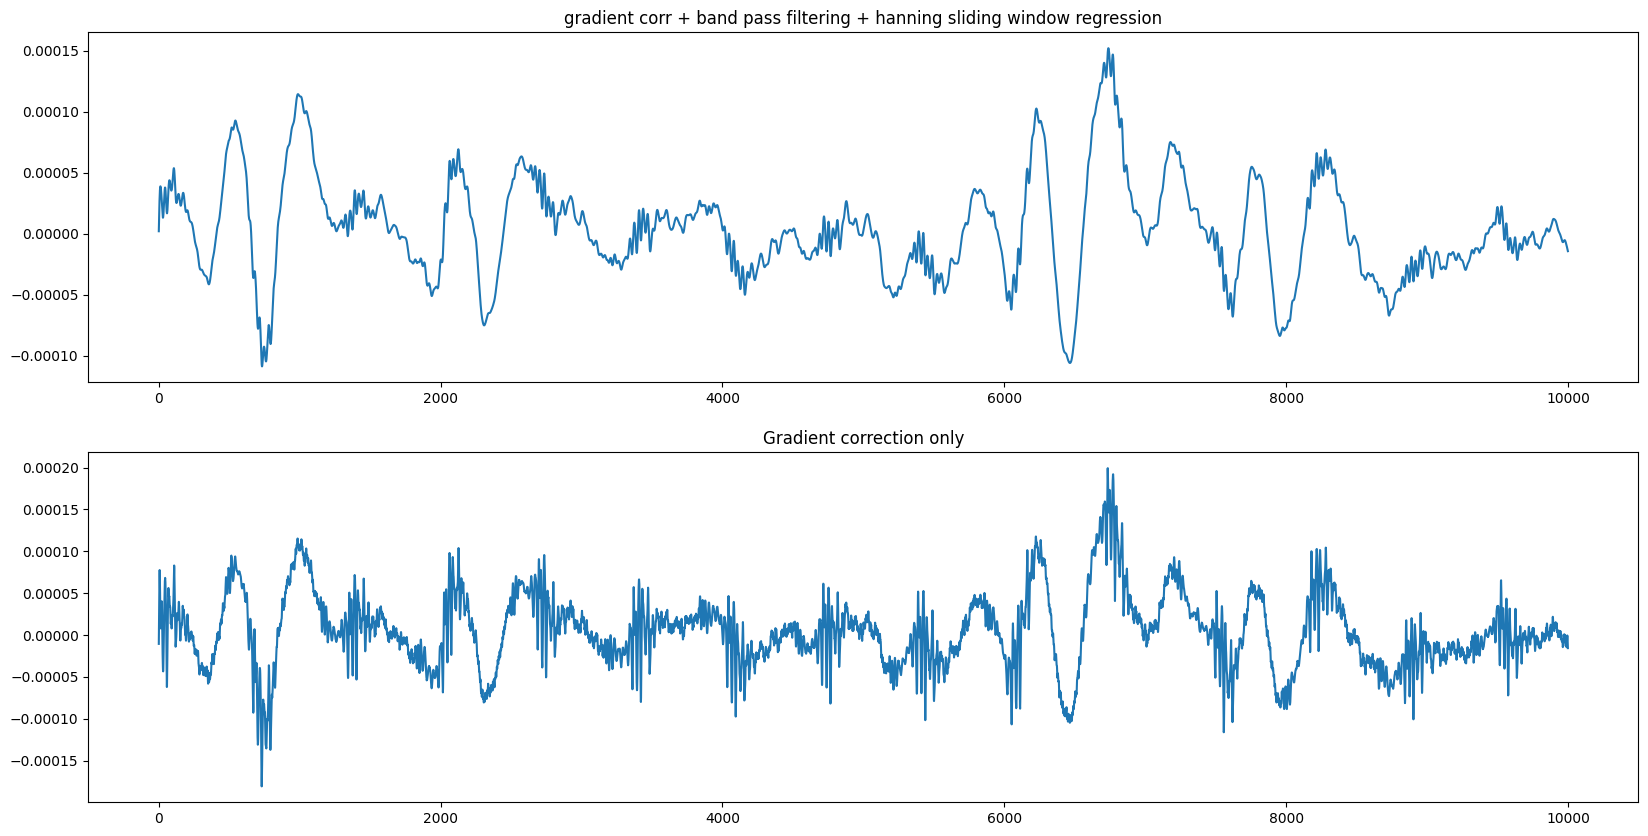

In [14]:
for c in ch:
    fig,ax = plt.subplots(2,1, figsize = (20,10))
    ax[0].set_title('gradient corr + band pass filtering + hanning sliding window regression')
    ax[0].plot(regression_corrected_df[f'{c}'].values[:10000])
    ax[1].set_title('Gradient correction only')
    ax[1].plot(df[f'{c}'].values[:10000])

